In [1]:
# IPython magig  tools
%load_ext autoreload
%autoreload 2

import os
from pathlib import Path

from aind_vr_foraging_analysis.utils.parsing import data_access, parse
import aind_vr_foraging_analysis.utils.plotting as plotting
import aind_vr_foraging_analysis.utils as processing


# Plotting libraries
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_pdf import PdfPages

import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime
import pytz

sns.set_context('talk')
from pathlib import Path
import warnings
pd.options.mode.chained_assignment = None  # Ignore SettingWithCopyWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Rectangle

color1='#d95f02'
color2='#1b9e77'
color3='#7570b3'
color4='yellow'
odor_list_color = [color1, color2, color3, color4]

pdf_path = r'Z:\scratch\vr-foraging\sessions'
foraging_figures = r'C:\Users\tiffany.ona\OneDrive - Allen Institute\Documents'

from scipy.optimize import curve_fit

color_dict_label = {'InterSite': '#808080',
    'InterPatch': '#b3b3b3', 
    'A': color1,
    'B': color2,
    'C': color3,
    'OdorA': color1,
    'OdorB': color2,
    'OdorC': color3,
    }

palette = {'High': color1, 'Medium': color2, 'Low': color3}

label_dict = {**{
"InterSite": '#808080',
"InterPatch": '#b3b3b3'}, 
            **color_dict_label}

# **One session exploration**

In [3]:
from aind_vr_foraging_analysis.utils.parsing import data_access
date_string = "2026-05-07" # YYYY-MM-DD
mouse_list = ['841302','841312','841301', '841300', '841299', '833608'] # mouse ID
df = pd.DataFrame()
vel = pd.DataFrame()

for mouse in mouse_list:
    # This section will look at all the session paths that fulfill the condition
    session_paths = data_access.find_sessions_relative_to_date(
        mouse=mouse,
        date_string=date_string,
        when='between',
        end_date_string='2026-05-16'
    )

    # # session_paths  = [Path(rf'Z:\scratch\vr-foraging\test\TestEphys5 - 19-01-26\828423_2026-01-19T200359Z')]
    # session_paths = [Path(rf'Z:\scratch\tiffany.ona\ephys\sessions\795133_2026-02-11_11-28-51')]

    # Iterate over the session paths and load the data
    for session_path in session_paths:
        # print(f"Loading {session_path.name}...")
        try:
            all_epochs, stream_data, data = data_access.load_session(
                session_path, extra=True
            )
        except:
            print(f"Error loading {session_path.name}. Skipping.")
            continue
        print(f"Loaded {session_path.name} successfully.")
        stage = data['config'].streams.tasklogic_input.data['stage_name']
        all_epochs['stage'] = stage
        
        reward_functions = data['config'].streams.tasklogic_input.data['task_parameters']['environment']['blocks'][0]['environment_statistics']['patches'][0]['reward_specification']['reward_function']

        prob_functions = [rf['probability']['function_type'] for rf in reward_functions]
        print(prob_functions)
        if 'CtcmFunction' in prob_functions:
            functions = 'replenish'
            
        else:
            functions = 'immediate'

        all_epochs['reward_functions'] = functions
        # if stage != "mcm_final_stage":
        #     continue
        
        # minimum = data['config'].streams.tasklogic_input.data['task_parameters']['environment']['blocks'][0]['environment_statistics']['patches'][0]['reward_specification']['reward_function'][0]['probability']['minimum']
        # # odor_sites = all_epochs.loc[all_epochs['label'] == 'OdorSite']
        # all_epochs['minimum_probability'] = minimum

        all_epochs['session'] = session_path.name
        all_epochs['mouse'] = mouse
        all_epochs['rig'] =  data['config'].streams.rig_input.data['rig_name']

        odor_sites = all_epochs.loc[all_epochs['label'] == 'OdorSite']
        trial_summary = plotting.trial_collection(odor_sites, stream_data.encoder_data, window = (-2, 2), aligned='succesful_wait_time')
        vel = pd.concat([vel, trial_summary])
        df = pd.concat([df, all_epochs])
# except Exception as e:
#     print(f"Error loading {session_path.name}: {e}")

{'harp_behavior': DataStreamSource from Z:\stage\vr-foraging\data\841302\841302_2026-05-07T161425Z\behavior\Behavior.harp, 'harp_olfactometer': DataStreamSource from Z:\stage\vr-foraging\data\841302\841302_2026-05-07T161425Z\behavior\Olfactometer.harp, 'harp_lickometer': DataStreamSource from Z:\stage\vr-foraging\data\841302\841302_2026-05-07T161425Z\behavior\Lickometer.harp, 'harp_sniffsensor': DataStreamSource from Z:\stage\vr-foraging\data\841302\841302_2026-05-07T161425Z\behavior\SniffDetector.harp, 'harp_stepperdriver': DataStreamSource from Z:\stage\vr-foraging\data\841302\841302_2026-05-07T161425Z\behavior\StepperDriver.harp, 'harp_clock': DataStreamSource from Z:\stage\vr-foraging\data\841302\841302_2026-05-07T161425Z\behavior\ClockGenerator.harp, 'harp_treadmill': DataStreamSource from Z:\stage\vr-foraging\data\841302\841302_2026-05-07T161425Z\behavior\Treadmill.harp, 'harp_environment_sensor': DataStreamSource from Z:\stage\vr-foraging\data\841302\841302_2026-05-07T161425Z\be

In [ ]:
df['time'] = df['session'].apply(lambda x: x.split('-')[-1])  # Extract the date part from the session name

In [4]:
df.to_csv(r'C:\git\Aind.Behavior.VrForaging.Analysis\data\summary_0507-0516.csv', index=False)

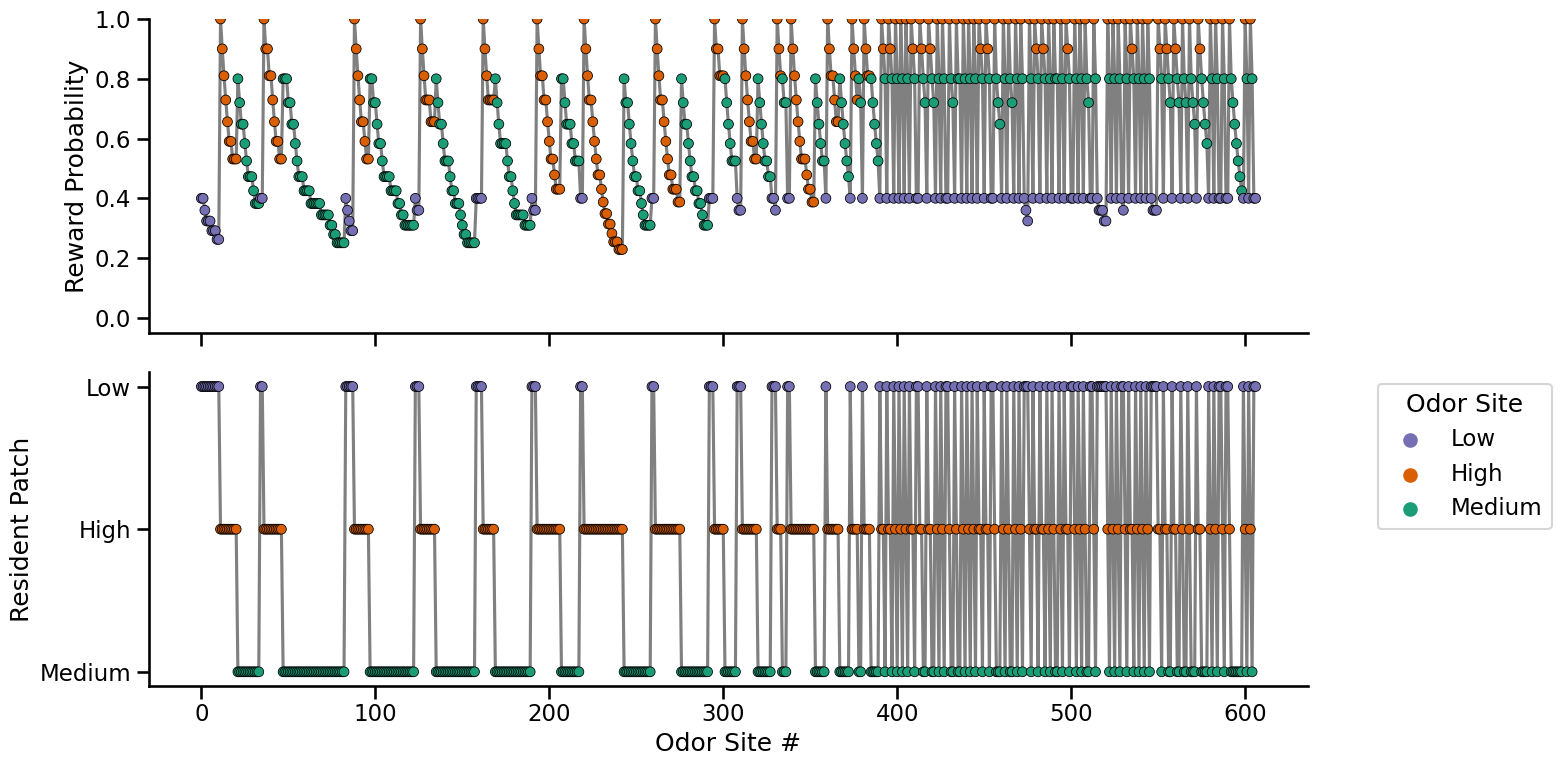

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes = ax[0]
sns.scatterplot(data=odor_sites, x='odor_sites', y='reward_probability', hue='patch_label', palette=palette, s=50, zorder=2, edgecolor='black', ax=axes, legend=False)
sns.lineplot(data=odor_sites, x='odor_sites', y='reward_probability', color='grey', zorder=1, ax=axes)
axes.set_ylim(-0.05, 1)
axes.set_ylabel('Reward Probability')

axes = ax[1]
sns.scatterplot(data=odor_sites, x='odor_sites', y='patch_label', hue='patch_label', palette=palette, s=50, zorder=2, edgecolor='black', ax=axes)
sns.lineplot(data=odor_sites, x='odor_sites', y='patch_label', color='grey', zorder=1, ax=axes)

axes.set_ylabel('Resident Patch')
axes.set_xlabel('Odor Site #')

plt.legend(title='Odor Site', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()

In [ ]:
# Summary of different relevants aspects -------------------------------------------------
unrewarded_stops = odor_sites.loc[odor_sites.is_reward==0]['is_choice'].count()
rewarded_stops = odor_sites.loc[odor_sites.is_reward==1]['is_choice'].count()
water_collected = odor_sites.loc[(odor_sites['is_reward']==1)]['reward_amount'].sum()
total_stops = odor_sites.loc[(odor_sites['is_choice']==True)]['reward_available'].count()

# Rewarded stops / total available rewarded stops
optimality = rewarded_stops / odor_sites[odor_sites.reward_available != 0]['is_reward'].count()

# Rewarded stops / Stops
efficiency = rewarded_stops / odor_sites.is_reward.sum()

print('Total sites: ' ,len(odor_sites), ' | ', 'Total rewarded stops: ',rewarded_stops, '(',  np.round((rewarded_stops/total_stops)*100,2),'%) | ', 
    'Total unrewarded stops: ',unrewarded_stops,'(',  np.round((unrewarded_stops/total_stops)*100,2),'%) | ','Water consumed: ', water_collected, 'ul')

if 'startPosition' in all_epochs.columns:
    stop_duration = np.round(all_epochs.startPosition.max()/100,2)
else:
    stop_duration = np.round(all_epochs.start_position.max()/100,2)
print('Total travelled m: ', np.round(all_epochs.start_position.max()/100,2))

for odor_label in odor_sites.patch_label.unique():
    values = odor_sites.loc[(odor_sites['patch_label']==odor_label)&(odor_sites['is_reward']==1)]['reward_amount'].sum()
    print(f'{odor_label} {values} ul')

Total sites:  248  |  Total rewarded stops:  99 ( 41.95 %) |  Total unrewarded stops:  149 ( 63.14 %) |  Water consumed:  396.0 ul
Total travelled m:  536.11
Medium 172.0 ul
Low 0.0 ul
High 224.0 ul


## Velocity - How long are they waiting after reward

In [ ]:
def plot_velocity_by_odor(
    trial_summary,
    mode="average_sessions",  # "average_sessions" | "example_session" | "average_mice"
    mouse_id=None,            # required for "average_sessions" and "example_session"
    session_id=None,          # required for "example_session"
    mouse_col="mouse",
    session_col="session",
    window=(-2, 2),
    show_mean=True,
):
    """
    Plot velocity traces by odor/reward condition.

    Parameters
    ----------
    trial_summary : pd.DataFrame
        Dataset containing all mice and sessions.
    mode : str
        - "average_sessions": average across all sessions for one mouse
        - "example_session": plot a single session for one mouse
        - "average_mice": average across all mice (grand average)
    mouse_id : str or int
        Mouse identifier. Required for "average_sessions" and "example_session".
    session_id : str or int
        Session identifier. Required for "example_session".
    window : tuple
        (start, end) time window in seconds around odor onset.
    show_mean : bool
        Whether to plot the mean line (always True for now, kept for extensibility).
    """

    # --- Input validation ---
    valid_modes = {"average_sessions", "example_session", "average_mice"}
    if mode not in valid_modes:
        raise ValueError(f"`mode` must be one of {valid_modes}, got '{mode}'")

    if mode in {"average_sessions", "example_session"} and mouse_id is None:
        raise ValueError(f"mode='{mode}' requires `mouse_id` to be specified.")

    if mode == "example_session" and session_id is None:
        raise ValueError("mode='example_session' requires `session_id` to be specified.")

    # --- Subset data based on mode ---
    if mode == "average_sessions":
        df = trial_summary[trial_summary['mouse'] == mouse_id].copy()
        subtitle = f"Mouse {mouse_id} — avg. across sessions"

    elif mode == "example_session":
        df = trial_summary[
            (trial_summary['mouse'] == mouse_id) &
            (trial_summary['session'] == session_id)
        ].copy()
        subtitle = f"Mouse {mouse_id} — session {session_id}"

    elif mode == "average_mice":
        df = trial_summary.copy()
        subtitle = "Grand average across all mice"

    if df.empty:
        raise ValueError("Filtered dataframe is empty. Check your mouse_id/session_id values.")

    # --- Shared plot setup ---
    max_range = 60
    n_odors = df.is_reward.unique()

    fig, axes = plt.subplots(
        1, len(n_odors),
        figsize=(len(n_odors) * 3.5, 4.5),
        sharex=True, sharey=True
    )
    if len(n_odors) == 1:
        axes = [axes]  # always iterate over a list

    fig.suptitle(subtitle, fontsize=11, y=1.02)

    for j, odor_label in enumerate(n_odors):
        ax = axes[j]

        # --- Axes formatting ---
        ax.set_xlabel("Time after \n water sample (s)")
        ax.set_title(f"Reward: {odor_label}")
        ax.set_ylim(-13, max_range)
        ax.set_xlim(window)

        if j == 0:
            ax.set_ylabel("Velocity (cm/s)")

        ax.hlines(5, window[0], window[1], color="black", linewidth=1, linestyles="dashed")

        # Shaded regions
        y_fill = np.arange(-20, max_range, 0.1)
        ax.vlines(0, -20, max_range, color="grey", alpha=0.5, linewidth=0)
        # --- Aggregate data based on mode ---
        if mode == "average_mice":
            # First average within each mouse, then across mice
            df_results = (
                df[df.is_reward == odor_label]
                .groupby(["mouse", "odor_sites", "times"])[["speed"]]
                .median()
                .reset_index()
                .groupby(["odor_sites", "times"])[["speed"]]
                .median()
                .reset_index()
            )
        else:
            # average_sessions or example_session: aggregate across trials
            df_results = (
                df[df.is_reward == odor_label]
                .groupby(["odor_sites", "times", "is_reward"])[["speed"]]
                .median()
                .reset_index()
            )

        if df_results.empty:
            continue

        if show_mean:
            sns.lineplot(
                x="times",
                y="speed",
                data=df_results,
                color="black",
                ci="sd",
                legend=False,
                # hue='mouse',
                linewidth=2,
                ax=ax,
            )

    sns.despine()
    plt.tight_layout()
    plt.show()

In [ ]:
# Custom column names or window
plot_velocity_by_odor(
    vel,
    mode="average_mice",
    mouse_id='841299',
    window=(-2, 2),
)

## Dynamic plots

In [ ]:
def add_position(df: pd.DataFrame, position:  pd.DataFrame):
    position.rename_axis('Time', axis='index', inplace=True)
    df.rename_axis('Time', axis='index', inplace=True)

    df = pd.merge_asof(df.sort_index(), position.sort_index(), direction='nearest', on="Time").set_index("Time").sort_index()
    df.columns = [*df.columns[:-1], 'Position']
    return df

def plot_patches(ax, navigation_mode, zero_index, _legend):
    """Plot the context patches based on the navigation mode."""
    _sites = add_position(all_epochs, position=stream_data.position_data)
    for idx, site in enumerate(all_epochs.iloc[:-1].iterrows()):
        site_label = site[1]["label"]
        if site_label == "Reward":
            site_label = f"Odor {site[1]['odor']['index'] + 1}"
            facecolor = label_dict[site_label]
        elif site_label == "OdorSite":
            site_label = site[1]['patch_label']
            facecolor = label_dict[site_label]
        elif site_label == "InterPatch":
            facecolor = label_dict[site_label]
        else:
            site_label = "InterSite"
            facecolor = label_dict["InterSite"]

        if navigation_mode == "space":
            position = _sites["Position"].values[idx]
            width = _sites["Position"].values[idx + 1] - position
            p = Rectangle((position, -2), width, 8, linewidth=0, facecolor=facecolor, alpha=0.5)
        else:
            time_position = all_epochs.index[idx] - zero_index
            width = all_epochs.index[idx + 1] - all_epochs.index[idx]
            p = Rectangle((time_position, -2), width, 8, linewidth=0, facecolor=facecolor, alpha=0.5)

        _legend[site_label] = p
        ax.add_patch(p)

def plot_behavioral_events(ax, navigation_mode,  zero_index, _legend):
    """
    Plot the behavioral events based on the selected navigation mode.
    """
    events = [
        ("SoftReward", data['software_events'].streams['GiveReward'].data, 3.5, 'red', 'x', 400),
        ("SoftTone", data['software_events'].streams['ChoiceFeedback'].data, 2.5, 'yellow', 'x', 400),
        ('ChoiceFeedback', stream_data.choice_feedback, 2.5, 'k', 's', 100),
        ('Lick', stream_data.lick_onset, 1, 'k', '|', 100),
        ('Reward', stream_data.give_reward, 3.5, 'mediumblue', '*',100),
        ('Odor Onset', odor_triggers_onset, 1.5, 'pink', '|',300),
        ('Odor Offset', odor_triggers_offset, 1.5, 'purple', '|',300)
       
    ]
    
    # _legend["Waits"] = axs.scatter(stream_data.succesfull_wait.index - zero_index,
    #     succesfull_wait.index*0 + 1.2,
    #     marker=".", s=s, lw=lw, c='green',
    #     label="Reward")
    
    for event_name, event_data, y_pos, color, marker, size in events:
        if navigation_mode == "time" or navigation_mode == "patch":
            # Plot events by time index
            _legend[event_name] = ax.scatter(event_data.index-zero_index, [y_pos] * len(event_data.index), label=event_name, color=color, marker=marker, s=size)
        else:
            # Plot events by position (space or patch mode)
            positions = add_position(event_data, stream_data.position_data)['Position'].values
            _legend[event_name] = ax.scatter(positions, [y_pos] * len(positions), label=event_name, color=color, marker=marker, s=size)

In [ ]:
# Define a dictionary to map navigation modes to corresponding limits and increments
nav_config = {
    "patch": {"increment": 1},  # For patches, we move one patch at a time
    "time": {"increment": 20},
    "space": {"increment": 750}
}

def update_plot(x_start, navigation_mode="time"):
    """
    Update the plot based on the selected navigation mode (space, time, or patch).
    
    Parameters:
    ----------
    x_start : float
        The starting value for the x-axis (time or position or patch number).
    navigation_mode : str
        Mode of navigation: 'patch', 'time', or 'space'.
    """
    zero_index = all_epochs.index[0]
    
    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(20, 4))
    
    # Get the configuration for the selected navigation mode
    nav_mode = nav_config.get(navigation_mode, nav_config["time"])  # Default to 'time' if mode is invalid
    
    if navigation_mode == "patch":
        # Get the start and end times of patches
        patch_start_times = all_epochs.loc[all_epochs['label'] == 'InterPatch'].index
        patch_end_times = patch_start_times[1:].append(pd.Index([all_epochs.index[-1]]))  # Next patch's start time as end time for the last one
        patches = list(zip(patch_start_times, patch_end_times))

        # Determine the current patch
        current_patch = int(x_start)  # Use the integer part of x_start as the patch index
        start, end = patches[current_patch]

        # Set the x-limits for the current patch
        ax.set_xlim(start - zero_index, end - zero_index)
        
    else:
        # Use the configured x-limits for time or space navigation
        ax.set_xlim(x_start, x_start + nav_mode.get("increment"))

    _legend = {}
    
    # Plot context patches (the "OdorSite", "InterPatch" regions)
    plot_patches(ax, navigation_mode, zero_index, _legend)
    
    # Plot behavioral events (e.g., ChoiceFeedback, Lick, ValveOpen)
    plot_behavioral_events(ax, navigation_mode,zero_index, _legend)
    
    # Plot the velocity curve
    ax2 = ax.twinx()
    if navigation_mode == "time" or navigation_mode == "patch":
        _legend["Velocity"] = ax2.plot(
            stream_data.encoder_data.index - zero_index,
            stream_data.encoder_data.filtered_velocity,
            c="k", label="Velocity", alpha=0.8
        )[0]
    else:
        _legend["Velocity"] = ax2.plot(add_position(stream_data.encoder_data.filtered_velocity, position=stream_data.position_data)["Position"].values, 
                                       stream_data.encoder_data.filtered_velocity.values, c="k", label="Encoder", alpha = 0.8)[0]
    
    
    # Customize axis labels, limits, and grid
    ax.set_yticklabels([])
    ax.set_yticks([])
    
    ax.set_xlabel("Time (s)" if navigation_mode != "space" else "VR Space (cm)")
    ax2.set_ylabel("Velocity (cm/s)")
    ax.set_ylim(bottom=-1, top=4)
    ax.set_yticks([0, 3])
    ax2.axhline(5, color='gray', linestyle='--', alpha=0.5)
    ax2.axhline(8, color='red', linestyle='--', alpha=0.5)
    ax2.yaxis.tick_left()  # Move the ticks to the left side
    ax2.yaxis.set_label_position("left")  # Place the label on the left side
    ax.grid(False)
    ax2.set_ylim((-10, 70))
    ax.legend(_legend.values(), _legend.keys(), bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)

# Define callback functions for the arrow buttons with different navigation logic based on the plot type
def on_left_button_clicked(button):
    # Adjust the x_start based on the selected navigation mode
    if navigation_mode_widget.value == "patch":
        x_start_widget.value -= 1  # Go to the previous patch
    else:
        x_start_widget.value -= nav_config[navigation_mode_widget.value]["increment"]  # Go left by increment

def on_right_button_clicked(button):
    # Adjust the x_start based on the selected navigation mode
    if navigation_mode_widget.value == "patch":
        x_start_widget.value += 1  # Go to the next patch
    else:
        x_start_widget.value += nav_config[navigation_mode_widget.value]["increment"]  # Go right by increment

def save_plot(button):
    fig, ax = update_plot(x_start_widget.value)  # Get the current plot
    save_name = "current_plot.png"  # Define the filename (you can modify this as needed)
    
    fig.savefig(save_name, bbox_inches='tight', pad_inches=0.1, transparent=True)
    print(f"Plot saved as {save_name}")
    
# Create arrow buttons
left_button = widgets.Button(description='◄')
right_button = widgets.Button(description='►')

# Create Save button
save_button = widgets.Button(description='Save Plot')

# Set the save button click event handler
save_button.on_click(save_plot)

# Define widget for the starting value of x-axis (space, time, or patch number)
x_start_widget = widgets.FloatText(value=0.0, description='X start:', continuous_update=False)

# Dropdown to select navigation mode (Space, Time, Patch)
navigation_mode_widget = widgets.Dropdown(
    options=['time', 'space','patch'],
    value='patch',
    description='Nav Mode:',
    disabled=False
)

# Set button click event handlers
left_button.on_click(on_left_button_clicked)
right_button.on_click(on_right_button_clicked)

# Arrange the buttons and widget horizontally
button_box = widgets.HBox([left_button, right_button, navigation_mode_widget, save_button])
ui = widgets.VBox([button_box, x_start_widget])

# Create interactive plot
interactive_plot = widgets.interactive_output(update_plot, {'x_start': x_start_widget, 'navigation_mode': navigation_mode_widget})

# Display the interactive plot and UI
display(ui, interactive_plot)


In [ ]:
fig = plt.figure(figsize=(16,4))
sns.lineplot(data=odor_sites, x='odor_sites', y='is_choice', hue='patch_label', palette=color_dict_label, alpha=0.7, marker = '.')
sns.despine()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

### Segments of the session with sniff data

Explore data but having the sniff data on top (it takes longer to plot)

In [ ]:
breathing_data = processing.fir_filter(stream_data.breathing, 'data', 100)
breathing_data = stream_data.breathing

In [ ]:
def update_plot(x_start):
    zero_index = all_epochs.index[0]

    fig, axs = plt.subplots(2,1, figsize=(12,6), gridspec_kw={'height_ratios': [2, 3]}, sharex=True)

    # sites_test = sites.loc[(sites.index > (zero_index + x_start))&(sites.index < (zero_index + x_start + 50))]   
    _legend = {}
    for idx, site in enumerate(all_epochs.iloc[:-1].iterrows()):
        site_label = site[1]["label"]
        if site_label == "Reward":
            site_label = f"Odor {site[1]['odor']['index']+1}"
            facecolor = label_dict[site_label]
        elif site_label == "OdorSite":
            site_label = site[1]['patch_label']
            facecolor = label_dict[site_label]
        elif site_label == "InterPatch":
            facecolor = label_dict[site_label]
        else:
            site_label = "InterSite"
            facecolor = label_dict["InterSite"]

        p = Rectangle(
            (all_epochs.index[idx] - zero_index, -2), all_epochs.index[idx+1] - all_epochs.index[idx], 8,
            linewidth = 0, facecolor = facecolor, alpha = .5)
        
        _legend[site_label] = p
        axs[0].add_patch(p)
        
        q = Rectangle(
            (all_epochs.index[idx] - zero_index, -2), all_epochs.index[idx+1] - all_epochs.index[idx], 8,
            linewidth = 0, facecolor = facecolor, alpha = .5)
        _legend[site_label] = q
        axs[1].add_patch(q)
        # axs[1].add_patch(p)
        
    s, lw = 400, 2
    # Plotting raster
    y_idx = -0.4
    _legend["Choice Tone"] = axs[1].scatter(stream_data.choice_feedback.index - zero_index+0.2,
            stream_data.choice_feedback.index * 0 + y_idx,
            marker="s", s=100, lw=lw, c='darkblue',
            label="Choice Tone")
    y_idx += 1
    _legend["Lick"] = axs[1].scatter(stream_data.lick_onset.index - zero_index,
            stream_data.lick_onset.index * 0 + y_idx,
            marker="|", s=s, lw=lw, c='k',
            label="Lick")
    _legend["Reward"] = axs[1].scatter(stream_data.give_reward.index - zero_index,
            stream_data.give_reward.index*0 + y_idx,
            marker=".", s=s, lw=lw, c='deepskyblue',
            label="Reward")
    # _legend["Waits"] = axs[1].scatter(stream_data.successfull_wait.index - zero_index,
    #     stream_data.successfull_wait.index*0 + 1.2,
    #     marker=".", s=s, lw=lw, c='green',
    #     label="Reward")
    # _legend["Odor_on"] = axs.scatter(odor_on - zero_index,
    #     odor_on*0 + 2.5,
    #     marker="|", s=s, lw=lw, c='pink',
    #     label="ON")
    
    # _legend["Odor_off"] = axs.scatter(odor_off - zero_index,
    #     odor_off*0 + 2.5,
    #     marker="|", s=s, lw=lw, c='purple',
    #     label="ON")
    
    y_idx += 1

    #ax.set_xticks(np.arange(0, sites.index[-1] - zero_index, 10))
    axs[1].set_yticklabels([])
    axs[1].set_xlabel("Time(s)")
    axs[1].set_ylim(bottom=-1, top = 3)
    axs[1].grid(False)

    ax2 = axs[1].twinx()
    _legend["Velocity"] = ax2.plot(stream_data.encoder_data.index - zero_index, stream_data.encoder_data.filtered_velocity, c="k", label="Encoder", alpha = 0.8)[0]
    try:
        v_thr = data['config'].streams.TaskLogic.data["operationControl"]["positionControl"]["stopResponseConfig"]["velocityThreshold"]
    except:
        v_thr = 8
    _legend["Stop Threshold"] = ax2.plot(ax2.get_xlim(), (v_thr, v_thr), c="k", label="Encoder", alpha = 0.5, lw = 2, ls = "--")[0]
    ax2.grid(False)
    ax2.set_ylim((-5, 70))
    ax2.set_ylabel("Velocity (cm/s)")

    ax3 = axs[0].twinx()
    _legend["Breathing"] = ax3.plot(breathing_data.index - zero_index, breathing_data.data.values, c="black", label="Breathing", alpha = 0.8)[0]
    # _legend["Breathing"] = ax3.plot(filtered_breathing.index - zero_index, filtered_breathing['data'].values, c="black", label="Breathing", alpha = 0.8)[0]

    ax3.grid(False)
    ax3.set_ylim(1000, 3000)
    ax3.set_ylabel("Breathing (au)")
    
    axs[0].legend(_legend.values(), _legend.keys(), bbox_to_anchor=(1.2, 0.1), loc='center left', borderaxespad=0.)

    # axs[0].stairs(software_events.streams.RewardAvailableInPatch.data["data"].values[:-1],
    #           software_events.streams.RewardAvailableInPatch.data["data"].index.values -  zero_index,
    #           lw = 3, color = 'k', fill=0)
    
    for i in [0,1]:
        axs[i].set_xlabel("Time(s)")
        axs[i].grid(False)
        axs[i].set_ylim(bottom=-1, top = 4)
        axs[i].set_yticks([])
        axs[i].yaxis.tick_right()
        axs[i].set_xlim([x_start, x_start + 5])
        
    plt.savefig(foraging_figures + f"\{x_start_widget.value}_time_detrended.svg", bbox_inches='tight', pad_inches=0.1, transparent=True)
    
# Define callback functions for the arrow buttons
def on_left_button_clicked(button):
    x_start_widget.value -= 10

def on_right_button_clicked(button):
    x_start_widget.value += 10

# Create arrow buttons
left_button = widgets.Button(description='◄')
right_button = widgets.Button(description='►')

# Define widget for the starting value of x-axis
x_start_widget = widgets.FloatText(value=00.0, description='X start:', continuous_update=False)

# Set button click event handlers
left_button.on_click(on_left_button_clicked)
right_button.on_click(on_right_button_clicked)

# Arrange the buttons and widget horizontally
button_box = widgets.HBox([left_button, right_button])
ui = widgets.VBox([button_box, x_start_widget])

# Create interactive plot
interactive_plot = widgets.interactive_output(update_plot, {'x_start': x_start_widget})

# Display the interactive plot and UI
display(ui, interactive_plot)